# Random Forest Model — Member 2

## Objectives

This notebook:

- Builds a Random Forest classifier without the leakage feature `duration`.
- Uses the same chronological train-test split as the Logistic Regression model.
- Compares three class-imbalance strategies:
  1. No imbalance handling
  2. Class weights
  3. SMOTE
- Uses stratified 5-fold cross-validation on the training set.
- Selects the best strategy mainly using PR-AUC and Recall.
- Tunes the best Random Forest model.
- Evaluates the final model once on the untouched chronological test set.

In [1]:
import sys
import csv
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
)

warnings.filterwarnings("ignore")

# Make imports work whether Jupyter starts from the repository root
# or from the notebooks folder.
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import CV_FOLDS, EXPERIMENT_LOG, RANDOM_STATE, ROOT
from src.rf_model import (
    build_rf_pipeline,
    chronological_split,
    load_data,
)

FIGURES_DIR = ROOT / "results" / "figures"
MODELS_DIR = ROOT / "models" / "experiments"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Random state:", RANDOM_STATE)
print("CV folds:", CV_FOLDS)

Project root: C:\Users\USER\Documents\GitHub\bank-telemarketing-predictor
Random state: 42
CV folds: 5


In [2]:
# load_data() performs the following:
# 1. Reads the original dataset
# 2. Removes exact duplicate rows
# 3. Removes duration to prevent data leakage
# 4. Converts target y: yes = 1 and no = 0

X, y = load_data()

# Use the same chronological 80/20 split as Member 1.
# Earlier records are used for training.
# The latest 20% of records are kept as the untouched test set.

X_train, X_test, y_train, y_test = chronological_split(
    X,
    y,
    test_fraction=0.20,
)

print("Full feature data shape:", X.shape)
print("Training feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(
    y_train.value_counts()
    .rename(index={0: "No", 1: "Yes"})
)

print("\nTraining target percentages:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename(index={0: "No", 1: "Yes"})
)

print("\nTest target percentages:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename(index={0: "No", 1: "Yes"})
)

print("\nDuration present in features:", "duration" in X.columns)

Full feature data shape: (41176, 19)
Training feature shape: (32940, 19)
Test feature shape: (8236, 19)

Training target distribution:
y
No     30840
Yes     2100
Name: count, dtype: int64

Training target percentages:
y
No     93.62
Yes     6.38
Name: proportion, dtype: float64

Test target percentages:
y
No     69.17
Yes    30.83
Name: proportion, dtype: float64

Duration present in features: False


## Class-Imbalance Strategy Comparison

Three Random Forest pipelines are compared:

1. **No handling** — original imbalanced training data.
2. **Class weight** — gives more importance to minority-class observations.
3. **SMOTE** — creates synthetic minority observations inside each training fold.

The untouched chronological test set is not used during this comparison.  
Stratified 5-fold cross-validation is performed only on the training set.

PR-AUC is the primary metric because the target class is highly imbalanced.
Recall is also important because it measures how many actual subscribers are identified.

In [3]:
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
}

imbalance_strategies = {
    "No handling": "none",
    "Class weight": "class_weight",
    "SMOTE": "smote",
}

comparison_rows = []

for strategy_name, strategy_value in imbalance_strategies.items():
    print(f"Evaluating: {strategy_name}...")

    model = build_rf_pipeline(
        imbalance_method=strategy_value,
        n_estimators=150,
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    comparison_rows.append(
        {
            "Strategy": strategy_name,
            "PR-AUC Mean": scores["test_pr_auc"].mean(),
            "PR-AUC Std": scores["test_pr_auc"].std(),
            "ROC-AUC Mean": scores["test_roc_auc"].mean(),
            "Recall Mean": scores["test_recall"].mean(),
            "Precision Mean": scores["test_precision"].mean(),
            "F1 Mean": scores["test_f1"].mean(),
        }
    )

    print(f"Completed: {strategy_name}")

imbalance_comparison = pd.DataFrame(comparison_rows)

imbalance_comparison = imbalance_comparison.sort_values(
    by="PR-AUC Mean",
    ascending=False,
).reset_index(drop=True)

display(
    imbalance_comparison.style.format(
        {
            "PR-AUC Mean": "{:.4f}",
            "PR-AUC Std": "{:.4f}",
            "ROC-AUC Mean": "{:.4f}",
            "Recall Mean": "{:.4f}",
            "Precision Mean": "{:.4f}",
            "F1 Mean": "{:.4f}",
        }
    )
)

Evaluating: No handling...
Completed: No handling
Evaluating: Class weight...
Completed: Class weight
Evaluating: SMOTE...
Completed: SMOTE


,Strategy,PR-AUC Mean,PR-AUC Std,ROC-AUC Mean,Recall Mean,Precision Mean,F1 Mean
0,No handling,0.1589,0.0095,0.6452,0.0857,0.3289,0.1358
1,Class weight,0.1575,0.0099,0.6469,0.0933,0.3335,0.1457
2,SMOTE,0.1540,0.0096,0.6442,0.0976,0.2992,0.1470


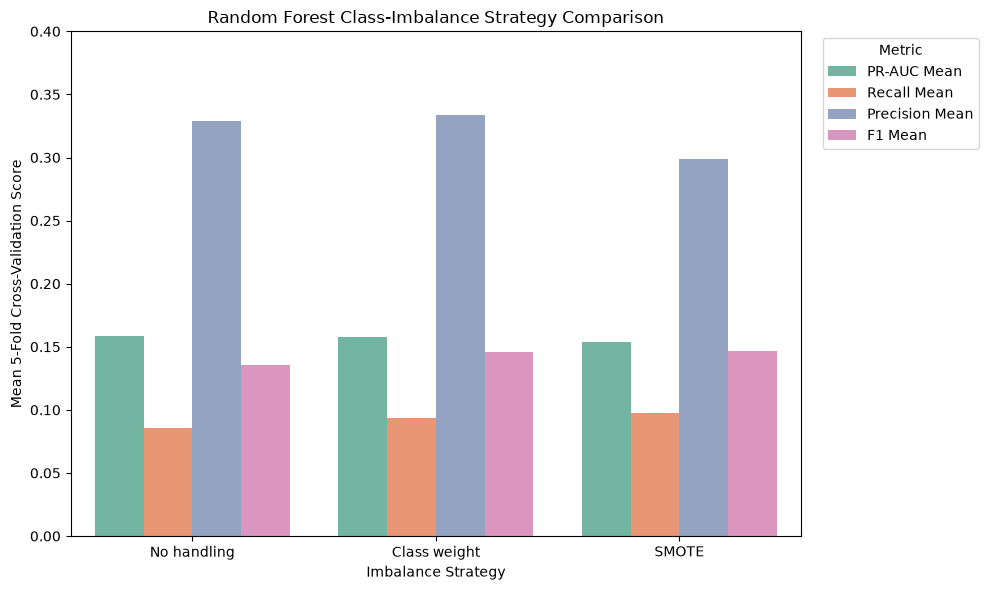

Figure saved to: C:\Users\USER\Documents\GitHub\bank-telemarketing-predictor\results\figures\rf_imbalance_strategy_comparison.png


In [4]:
# Convert the selected metrics to a long format for plotting.

plot_data = imbalance_comparison.melt(
    id_vars="Strategy",
    value_vars=[
        "PR-AUC Mean",
        "Recall Mean",
        "Precision Mean",
        "F1 Mean",
    ],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="Strategy",
    y="Score",
    hue="Metric",
    palette="Set2",
)

plt.title("Random Forest Class-Imbalance Strategy Comparison")
plt.xlabel("Imbalance Strategy")
plt.ylabel("Mean 5-Fold Cross-Validation Score")
plt.ylim(0, 0.40)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

comparison_figure_path = (
    FIGURES_DIR / "rf_imbalance_strategy_comparison.png"
)

plt.savefig(
    comparison_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:", comparison_figure_path)

### Selected Imbalance Strategy

The model without imbalance handling achieved the highest mean PR-AUC of 0.1589.  
SMOTE achieved the highest recall of 0.0976, but reduced PR-AUC and precision.

Class weighting was selected for hyperparameter tuning because it maintained a
PR-AUC close to the best result while improving recall and achieving the highest
precision. It also avoids generating synthetic categorical observations.

This experiment shows that SMOTE was tested correctly inside cross-validation,
but it did not provide the best overall performance for this dataset.

## Random Forest Hyperparameter Tuning

The class-weighted Random Forest is tuned using RandomizedSearchCV.

The following hyperparameters are investigated:

- `n_estimators`: number of trees in the forest.
- `max_depth`: maximum depth of each tree.
- `min_samples_split`: minimum observations needed to split a node.
- `min_samples_leaf`: minimum observations required in a leaf.
- `max_features`: number of features considered at each split.

The search uses stratified 5-fold cross-validation and PR-AUC as the primary
selection metric. The chronological test set remains untouched.

In [5]:
# Build the selected class-weighted Random Forest pipeline.

rf_for_tuning = build_rf_pipeline(
    imbalance_method="class_weight"
)

# Parameter names begin with classifier__ because the Random Forest
# is stored in the "classifier" step of the pipeline.

parameter_distributions = {
    "classifier__n_estimators": [100, 150, 200, 300],
    "classifier__max_depth": [None, 8, 12, 16, 20],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", 0.5],
}

random_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=parameter_distributions,
    n_iter=12,
    scoring="average_precision",
    cv=cv,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2,
    return_train_score=True,
)

print("Starting Random Forest hyperparameter tuning...")
print("This search will perform 12 combinations × 5 folds = 60 fits.")

random_search.fit(X_train, y_train)

print("\nTuning completed.")
print("Best cross-validation PR-AUC:", round(random_search.best_score_, 4))

print("\nBest parameters:")
for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

Starting Random Forest hyperparameter tuning...
This search will perform 12 combinations × 5 folds = 60 fits.
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=1, classifier__min_samples_split=5, classifier__n_estimators=100; total time=   5.8s
[CV] END classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=1, classifier__min_samples_split=5, classifier__n_estimators=100; total time=   9.7s
[CV] END classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=1, classifier__min_samples_split=5, classifier__n_estimators=100; total time=   9.7s
[CV] END classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=1, classifier__min_samples_split=5, classifier__n_estimators=100; total time=  10.1s
[CV] END classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=1, classifier_

In [6]:
best_rf_model = random_search.best_estimator_
best_cv_pr_auc = random_search.best_score_

best_parameters = pd.DataFrame(
    {
        "Hyperparameter": [
            parameter.replace("classifier__", "")
            for parameter in random_search.best_params_.keys()
        ],
        "Selected Value": [
            str(value)
            for value in random_search.best_params_.values()
        ],
    }
)

print("Best cross-validation PR-AUC:", round(best_cv_pr_auc, 4))
display(best_parameters)

Best cross-validation PR-AUC: 0.2166


,Hyperparameter,Selected Value
0,n_estimators,200
1,min_samples_split,20
2,min_samples_leaf,2
3,max_features,0.5
4,max_depth,8


## Final Evaluation on the Untouched Test Set

The best model selected using training-set cross-validation is now evaluated
once on the chronological test set.

The test set was not used for imbalance-strategy selection or hyperparameter
tuning. A default probability threshold of 0.50 is used for classification.

In [7]:
# RandomizedSearchCV has already refitted the best pipeline
# using the complete training dataset.

test_probabilities = best_rf_model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= 0.50).astype(int)

test_metrics = {
    "PR-AUC": average_precision_score(
        y_test,
        test_probabilities,
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        test_probabilities,
    ),
    "Recall": recall_score(
        y_test,
        test_predictions,
    ),
    "Precision": precision_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "F1 Score": f1_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
}

test_metrics_table = pd.DataFrame(
    {
        "Metric": test_metrics.keys(),
        "Test Score": test_metrics.values(),
    }
)

display(
    test_metrics_table.style.format(
        {"Test Score": "{:.4f}"}
    )
)

,Metric,Test Score
0,PR-AUC,0.4459
1,ROC-AUC,0.6536
2,Recall,0.4777
3,Precision,0.4259
4,F1 Score,0.4503


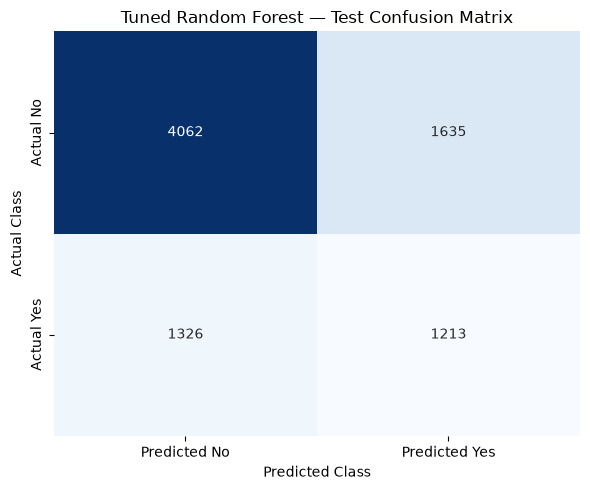

True negatives: 4062
False positives: 1635
False negatives: 1326
True positives: 1213
Figure saved to: C:\Users\USER\Documents\GitHub\bank-telemarketing-predictor\results\figures\rf_test_confusion_matrix.png


In [8]:
test_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions,
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted No", "Predicted Yes"],
    yticklabels=["Actual No", "Actual Yes"],
)

plt.title("Tuned Random Forest — Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

confusion_matrix_path = (
    FIGURES_DIR / "rf_test_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

tn, fp, fn, tp = test_confusion_matrix.ravel()

print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)
print("Figure saved to:", confusion_matrix_path)

## Precision–Recall Curve

The Precision–Recall curve evaluates the trade-off between identifying more
actual subscribers and keeping positive predictions accurate.

The horizontal baseline represents the positive-class proportion in the
chronological test set.

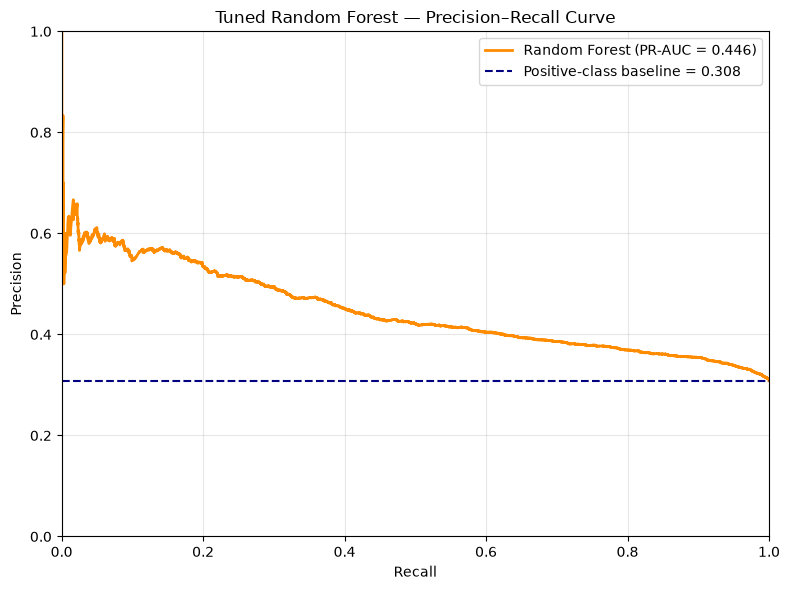

Figure saved to: C:\Users\USER\Documents\GitHub\bank-telemarketing-predictor\results\figures\rf_test_precision_recall_curve.png


In [9]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    test_probabilities,
)

test_pr_auc = test_metrics["PR-AUC"]
positive_baseline = y_test.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    color="darkorange",
    linewidth=2,
    label=f"Random Forest (PR-AUC = {test_pr_auc:.3f})",
)

plt.axhline(
    y=positive_baseline,
    color="navy",
    linestyle="--",
    label=f"Positive-class baseline = {positive_baseline:.3f}",
)

plt.title("Tuned Random Forest — Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

pr_curve_path = FIGURES_DIR / "rf_test_precision_recall_curve.png"

plt.savefig(
    pr_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:", pr_curve_path)

## Random Forest Feature Importance

Feature importance shows which encoded predictors contributed most to the
Random Forest's decisions.

These values describe predictive contribution, not causal relationships.

,Feature,Importance
0,numeric__cons.conf.idx,0.1973
1,numeric__euribor3m,0.1667
2,numeric__age,0.0672
3,numeric__cons.price.idx,0.0637
4,numeric__campaign,0.0449
5,numeric__emp.var.rate,0.0449
6,categorical__month_oct,0.0437
7,numeric__nr.employed,0.0395
8,categorical__default_no,0.0155
9,categorical__age_group_35-44,0.0145


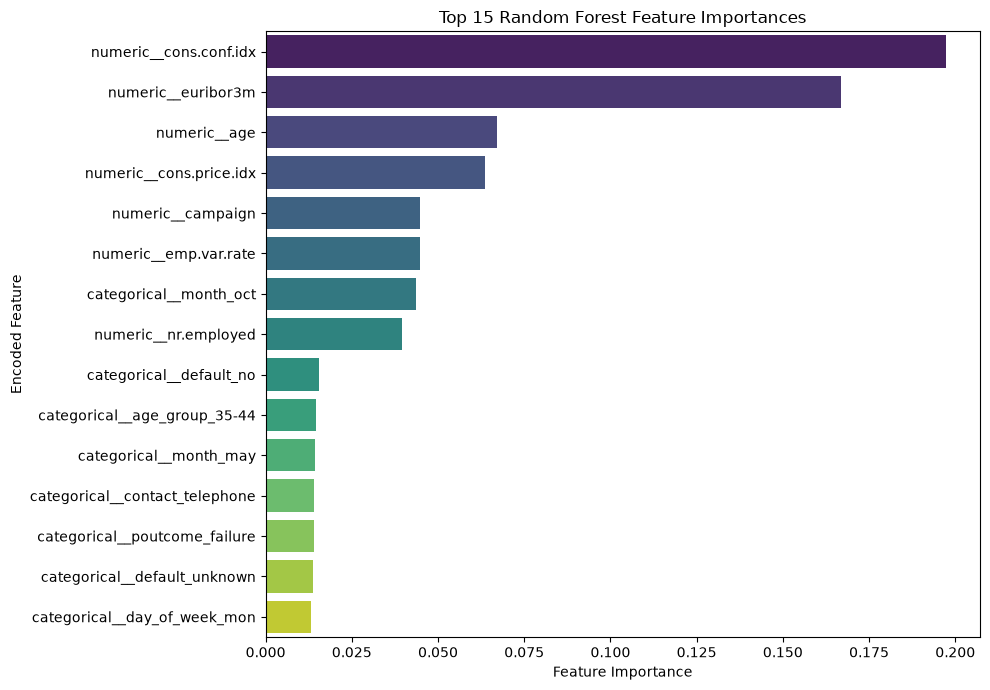

Figure saved to: C:\Users\USER\Documents\GitHub\bank-telemarketing-predictor\results\figures\rf_feature_importance.png


In [10]:
preprocessor = best_rf_model.named_steps["preprocessor"]
classifier = best_rf_model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()
feature_importances = classifier.feature_importances_

importance_table = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": feature_importances,
        }
    )
    .sort_values(
        by="Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

top_features = importance_table.head(15).copy()

display(
    top_features.style.format(
        {"Importance": "{:.4f}"}
    )
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Encoded Feature")
plt.tight_layout()

feature_importance_path = (
    FIGURES_DIR / "rf_feature_importance.png"
)

plt.savefig(
    feature_importance_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:", feature_importance_path)

## Lift and Cumulative Gain

Customers are ranked from the highest to the lowest predicted subscription
probability.

The cumulative-gain curve shows the percentage of actual subscribers captured
by targeting a given percentage of customers. Lift compares this result with
random customer selection.

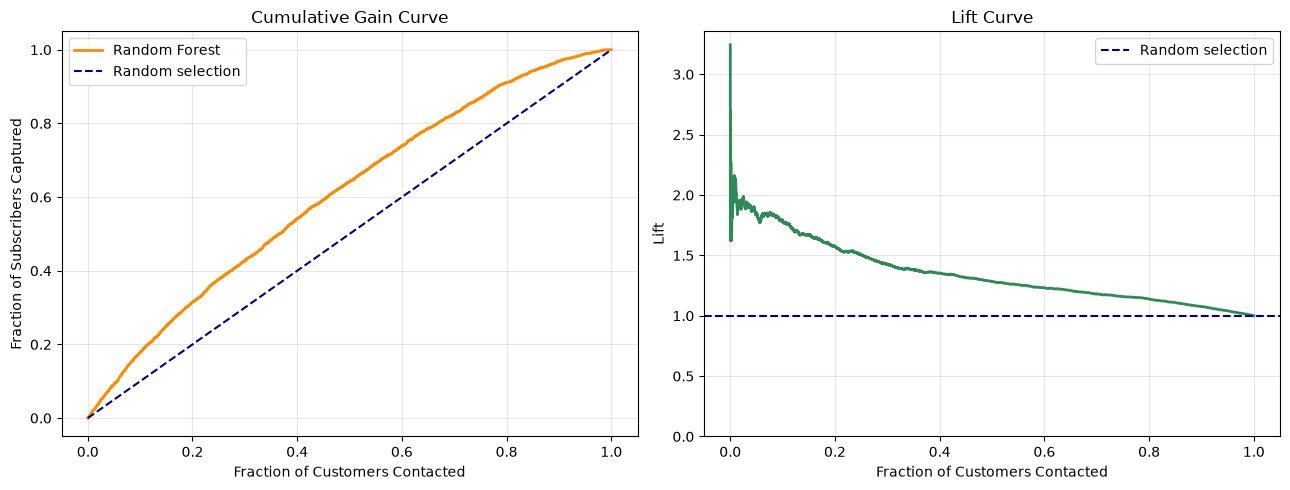

Top 10% customer gain: 17.88%
Top 10% customer lift: 1.79
Figure saved to: C:\Users\USER\Documents\GitHub\bank-telemarketing-predictor\results\figures\rf_lift_and_gain.png


In [11]:
ranking_table = pd.DataFrame(
    {
        "Actual": y_test.to_numpy(),
        "Probability": test_probabilities,
    }
).sort_values(
    by="Probability",
    ascending=False,
).reset_index(drop=True)

ranking_table["Population Fraction"] = (
    np.arange(1, len(ranking_table) + 1)
    / len(ranking_table)
)

ranking_table["Cumulative Positives"] = (
    ranking_table["Actual"].cumsum()
)

ranking_table["Cumulative Gain"] = (
    ranking_table["Cumulative Positives"]
    / ranking_table["Actual"].sum()
)

ranking_table["Lift"] = (
    ranking_table["Cumulative Gain"]
    / ranking_table["Population Fraction"]
)

# Add the origin for the cumulative-gain plot.
gain_x = np.insert(
    ranking_table["Population Fraction"].to_numpy(),
    0,
    0,
)

gain_y = np.insert(
    ranking_table["Cumulative Gain"].to_numpy(),
    0,
    0,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    gain_x,
    gain_y,
    linewidth=2,
    color="darkorange",
    label="Random Forest",
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="navy",
    label="Random selection",
)

axes[0].set_title("Cumulative Gain Curve")
axes[0].set_xlabel("Fraction of Customers Contacted")
axes[0].set_ylabel("Fraction of Subscribers Captured")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    ranking_table["Population Fraction"],
    ranking_table["Lift"],
    linewidth=2,
    color="seagreen",
)

axes[1].axhline(
    y=1,
    linestyle="--",
    color="navy",
    label="Random selection",
)

axes[1].set_title("Lift Curve")
axes[1].set_xlabel("Fraction of Customers Contacted")
axes[1].set_ylabel("Lift")
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()

lift_gain_path = FIGURES_DIR / "rf_lift_and_gain.png"

plt.savefig(
    lift_gain_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

top_10_count = max(1, int(len(ranking_table) * 0.10))
top_10_gain = ranking_table.loc[
    top_10_count - 1,
    "Cumulative Gain",
]
top_10_lift = ranking_table.loc[
    top_10_count - 1,
    "Lift",
]

print(
    f"Top 10% customer gain: {top_10_gain:.2%}"
)
print(
    f"Top 10% customer lift: {top_10_lift:.2f}"
)
print("Figure saved to:", lift_gain_path)

## Save Model and Experiment Results

The complete fitted pipeline is saved, including feature engineering,
categorical encoding, preprocessing, class-weight handling, and the tuned
Random Forest classifier.

In [12]:
model_path = MODELS_DIR / "rf_tuned.joblib"
importance_path = ROOT / "results" / "rf_feature_importance.csv"

joblib.dump(
    best_rf_model,
    model_path,
)

importance_table.to_csv(
    importance_path,
    index=False,
)

print("Model saved to:", model_path)
print("Feature importance saved to:", importance_path)

Model saved to: C:\Users\USER\Documents\GitHub\bank-telemarketing-predictor\models\experiments\rf_tuned.joblib
Feature importance saved to: C:\Users\USER\Documents\GitHub\bank-telemarketing-predictor\results\rf_feature_importance.csv


In [13]:
experiment_columns = [
    "model",
    "params",
    "cv_pr_auc",
    "test_pr_auc",
    "test_roc_auc",
    "recall",
    "precision",
    "f1",
    "notes",
]

experiment_row = {
    "model": "Random Forest - Tuned Class Weight",
    "params": str(random_search.best_params_),
    "cv_pr_auc": round(best_cv_pr_auc, 6),
    "test_pr_auc": round(test_metrics["PR-AUC"], 6),
    "test_roc_auc": round(test_metrics["ROC-AUC"], 6),
    "recall": round(test_metrics["Recall"], 6),
    "precision": round(test_metrics["Precision"], 6),
    "f1": round(test_metrics["F1 Score"], 6),
    "notes": (
        "Chronological 80/20 holdout; duration removed; "
        "class weighting selected after comparison with no handling "
        "and SMOTE; RandomizedSearchCV with stratified 5-fold CV."
    ),
}

if EXPERIMENT_LOG.exists():
    experiment_log = pd.read_csv(EXPERIMENT_LOG)

    # Prevent duplicate rows if this cell is run again.
    experiment_log = experiment_log[
        experiment_log["model"] != experiment_row["model"]
    ]

    experiment_log = pd.concat(
        [
            experiment_log,
            pd.DataFrame([experiment_row]),
        ],
        ignore_index=True,
    )
else:
    experiment_log = pd.DataFrame(
        [experiment_row],
        columns=experiment_columns,
    )

experiment_log.to_csv(
    EXPERIMENT_LOG,
    index=False,
)

display(experiment_log.tail())

print("Experiment log updated:", EXPERIMENT_LOG)

,model,params,cv_pr_auc,test_pr_auc,test_roc_auc,recall,precision,f1,notes
2,LogisticRegression (baseline),C=1;l2;class_weight=balanced,0.202700,0.505200,0.700700,0.847600,0.359900,0.505300,Member 1; threshold 0.5
3,LogisticRegression (tuned),{'clf__C': 1; 'clf__l1_ratio': 0.0},0.202700,0.505200,0.700700,0.847600,0.359900,0.505300,Member 1; threshold 0.5; best-F1 thr 0.720; 20...
4,XGBoost (baseline),defaults;scale_pos_weight=14.69,0.180500,0.366600,0.561200,0.177600,0.400200,0.246000,Member 3; chronological hold-out (primary); th...
5,"XGBoost (baseline, stratified split)",defaults;scale_pos_weight=7.88,0.427000,0.453600,0.795400,0.633600,0.383600,0.477900,Member 3; stratified split (secondary); thresh...
6,Random Forest - Tuned Class Weight,"{'classifier__n_estimators': 200, 'classifier_...",0.216583,0.445909,0.653604,0.477747,0.425913,0.450343,Chronological 80/20 holdout; duration removed;...


Experiment log updated: C:\Users\USER\Documents\GitHub\bank-telemarketing-predictor\results\experiment_log.csv


## Final Conclusion

A leakage-safe Random Forest model was developed to predict term-deposit
subscription using only information available before the marketing call.

### Main findings

- Exact duplicate rows were removed before modelling.
- The `duration` feature was excluded because it is only known after the call
  and would cause data leakage.
- A chronological 80/20 holdout was used to evaluate future-period
  generalisation.
- No handling, class weighting, and SMOTE were compared using stratified
  5-fold cross-validation.
- SMOTE produced the highest initial recall but reduced PR-AUC and precision.
- Class weighting was selected as the best balanced strategy.
- RandomizedSearchCV was used to tune the Random Forest hyperparameters.

### Final model performance

- Cross-validation PR-AUC: **0.2166**
- Test PR-AUC: **0.4459**
- Test ROC-AUC: **0.6536**
- Test Recall: **0.4777**
- Test Precision: **0.4259**
- Test F1 Score: **0.4503**
- Top 10% customer lift: **1.79**

The model identified approximately 47.8% of actual subscribers at the default
0.50 threshold. The top 10% of ranked customers contained 17.88% of all
subscribers, providing a lift of 1.79 over random customer selection.

The results also show temporal distribution shift between the training and
test periods. Therefore, the model should be monitored and periodically
retrained when used with newer campaign data.